# Lavaca Bay SFINCS Tutorial — Python API

This notebook demonstrates how to build and run a
[SFINCS](https://sfincs.readthedocs.io) coastal flood model for
Lavaca Bay, Texas using the `coastal_calibration` Python API.

The workflow has three phases:

1. **Create** — build a SFINCS model from an Area of Interest (AOI)
   polygon using HydroMT-SFINCS.
2. **Run** — execute the full simulation pipeline: download forcing
   data, write SFINCS input files, run the model, produce a
   downscaled flood depth map, and compare results against NOAA
   tide-gauge observations.
3. **Visualize** — plot the flood depth map and station comparisons.

## Setup

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "texas-lavaca")

## 1. Create the SFINCS model

### Build the create configuration

`SfincsCreateConfig.from_dict` accepts a plain dictionary with the same
structure as the YAML file.

In [ ]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./aoi.geojson",
        "output_dir": "./output",
        "download_dir": "../downloads/lavaca_grid",
        "grid": {
            "resolution": 512,
            "crs": "utm",
            "rotated": False,
            "refinement": [
                {"polygon": "./refine.geojson", "level": 3},
            ],
        },
        "elevation": {
            "datasets": [
                {"name": "noaa_3m", "zmin": -20000, "source": "noaa_3m"},
                {"name": "gebco_15arcs", "zmin": -20000, "source": "gebco_15arcs"},
            ],
            "buffer_cells": 1,
        },
        "mask": {"zmin": -50.0, "boundary_zmax": -1.0, "reset_bounds": True},
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        "add_noaa_gages": True,
    }
)

### Run the create workflow

In [ ]:
creator = SfincsCreator(create_config)
result = creator.run()
if not result.success:
    raise RuntimeError(f"Model creation failed at stage '{result.stages_failed}': {result.errors}")
print(result)

    noaa_8773037: no wet cell within 1000 m (nearest 9976 m away)               


WorkflowResult: SUCCESS
  Start:     2026-03-06 13:08:14
  End:       2026-03-06 13:08:45
  Duration:  31s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_subgrid, create_obs, create_write


### Inspect the created model

In [ ]:
output = Path("output")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} — run the create step first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.0 KB
  create_result.json             1.1 KB
  gis                            0.1 KB
  obs_station_map.json           0.5 KB
  sfincs.inp                     0.9 KB
  sfincs.nc                      15.2 MB
  sfincs.obs                     0.2 KB
  sfincs_subgrid.nc              23.0 MB
  subgrid                        0.2 KB


## 2. Run the simulation pipeline

### Build the run configuration

`CoastalCalibConfig.from_dict` accepts the same dictionary structure as
the run YAML file.

In [ ]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2025-06-01",
            "duration_hours": 10,
            "coastal_domain": "atlgulf",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./output",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": 0.0,
            "vdatum_mesh_to_msl_m": 0.30,
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            # SFINCS executable path. Either:
            #   1. Compile SFINCS and set the path here, or
            #   2. Remove this key to use Singularity (requires ngen-coastal.sif)
            "sfincs_exe": "~/.local/bin/sfincs",
            "inp_overrides": {
                "tspinup": 10800,
                "advection": 0,
                "viscosity": 0,
                "nuvisc": 0.01,
                "cdnrb": 3,
                "cdwnd": [0.0, 28.0, 50.0],
                "cdval": [0.001, 0.0025, 0.0025],
            },
            # Flood depth map — path to a high-resolution DEM.
            # Here we reuse the NOAA 3m DEM fetched during model creation.
            "floodmap_dem": "../downloads/lavaca_grid/noaa_3m.tif",
        },
    }
)

### Note on the SFINCS executable

The `sfincs_exe` field points to a compiled SFINCS binary.
You have two options:

1. **Compile SFINCS** yourself and update the path if it differs
   from `~/.local/bin/sfincs`.
2. **Use Singularity** — remove the `sfincs_exe` key from the dict.
   The pipeline will then use the `ngen-coastal.sif` Singularity image.

If neither is available, the pipeline will complete all stages up to
`sfincs_run` and then fail at model execution.

### Run the pipeline

In [ ]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Model creation failed at stage '{result.stages_failed}': {result.errors}")
print(result)

WorkflowResult: SUCCESS
  Start:     2026-03-06 13:08:45
  End:       2026-03-06 13:10:30
  Duration:  1m 44s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 3. View results

The pipeline generates station comparison plots (modelled vs. observed
water levels at NOAA CO-OPS tide gauges).

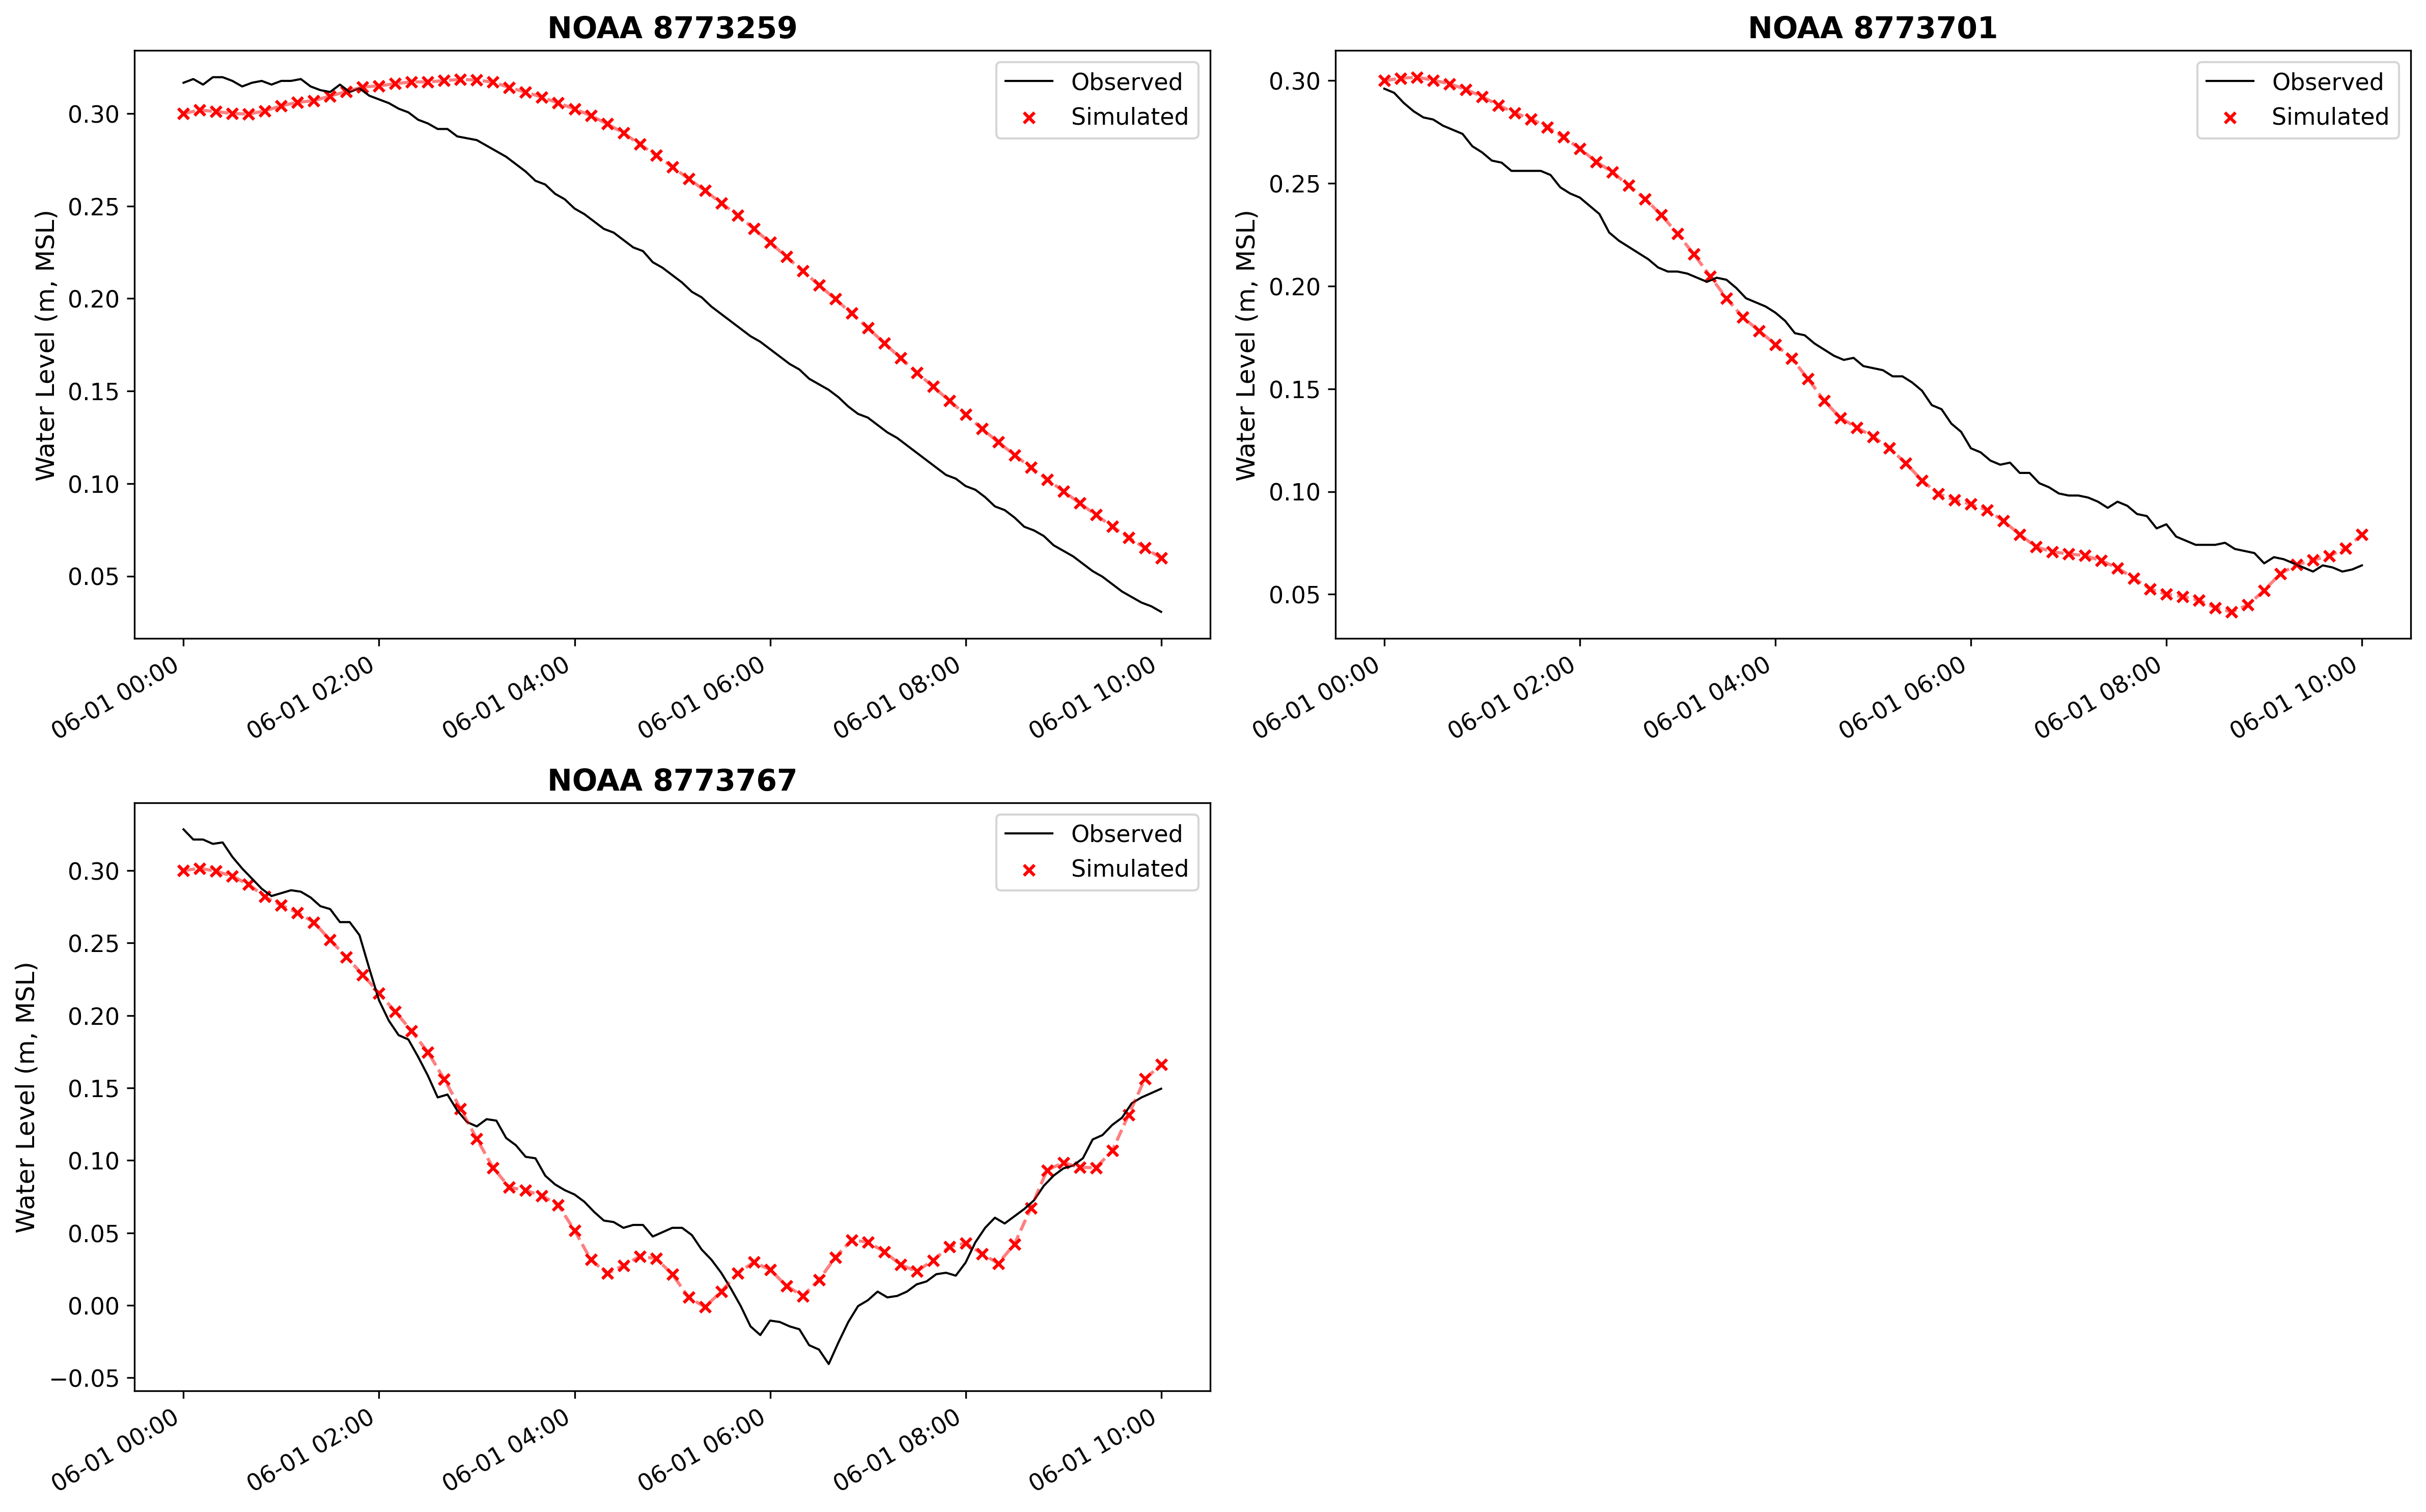

In [ ]:
from IPython.display import Image, display

figs_dir = Path("run/sfincs_model/figs")
assert figs_dir.exists(), f"Results not found: {figs_dir.resolve()} — run the pipeline first."

for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## 4. Quadtree mesh

The SFINCS model uses a quadtree grid with local refinement.  Coarser
cells (512 m) cover the offshore domain while regions near the coastline
and inside the bay are refined to smaller cell sizes (down to 64 m).
The map output file (`sfincs_map.nc`) stores the mesh as standard UGRID
quadrilaterals — opening it in QGIS with *native mesh rendering*
immediately shows the refinement structure.

In [ ]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import xugrid as xu
from matplotlib.collections import PolyCollection
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from pyproj import CRS, Transformer

map_file = Path("run/sfincs_model/sfincs_map.nc")
assert map_file.exists(), f"Map output not found: {map_file.resolve()} — run the pipeline first."

ds = xu.open_dataset(map_file)
grid = ds.ugrid.grid
grid_crs = CRS.from_epsg(int(ds["inp"].attrs["epsg"]))

# Derive refinement level from cell size (the grid is in UTM metres).
fnc = grid.face_node_connectivity  # (n_face, 4) — all quads
node_x, node_y = grid.node_x, grid.node_y
cell_width = node_x[fnc].max(axis=1) - node_x[fnc].min(axis=1)
base_res = 512
level = np.round(np.log2(base_res / cell_width) + 1).astype(int)

# Print grid summary
levels, counts = np.unique(level, return_counts=True)
print(f"  Grid CRS:  EPSG:{grid_crs.to_epsg()}")
print(f"  Faces:     {grid.n_face:,}")
print(f"  Edges:     {grid.n_edge:,}")
for lv, cnt in zip(levels, counts, strict=True):
    print(f"  Level {lv}:   {cnt:>6,} cells ({base_res / 2 ** (lv - 1):.0f} m)")

  Grid CRS:  EPSG:32614
  Faces:     70,723
  Edges:     282,892
  Level 1:   23,471 cells (512 m)
  Level 2:      545 cells (256 m)
  Level 3:    1,087 cells (128 m)
  Level 4:   45,620 cells (64 m)


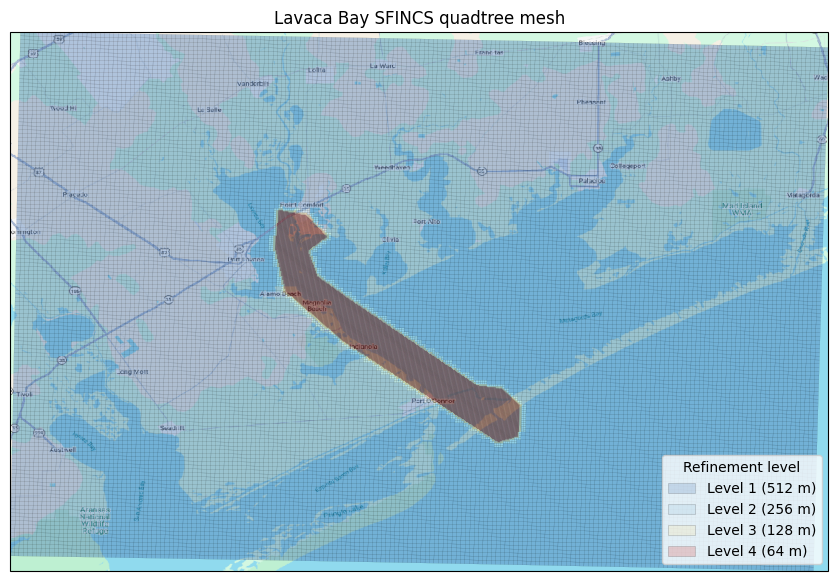

In [ ]:
# Transform node coordinates to geographic CRS for the cartopy overlay.
transformer = Transformer.from_crs(grid_crs, "EPSG:4326", always_xy=True)
node_lon, node_lat = transformer.transform(node_x, node_y)

# Build vertex arrays for PolyCollection (all faces are quads).
n_verts = fnc.shape[1]
verts = np.zeros((grid.n_face, n_verts, 2))
for j in range(n_verts):
    verts[:, j, 0] = node_lon[fnc[:, j]]
    verts[:, j, 1] = node_lat[fnc[:, j]]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent(
    [node_lon.min(), node_lon.max(), node_lat.min(), node_lat.max()],
    crs=ccrs.PlateCarree(),
)

# Satellite background
tiles = cimgt.GoogleTiles(style="street")
ax.add_image(tiles, 11)

# Overlay mesh cells colored by refinement level
colors = ["#4575b4", "#91bfdb", "#fee090", "#d73027"]
cmap = ListedColormap(colors)
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], ncolors=4)

pc = PolyCollection(verts, edgecolors="black", linewidths=0.1, alpha=0.4)
pc.set_array(level.astype(float))
pc.set_cmap(cmap)
pc.set_norm(norm)
ax.add_collection(pc)

# Legend
legend_handles = [
    Patch(
        facecolor=cmap(norm(lv)),
        edgecolor="black",
        linewidth=0.5,
        alpha=0.2,
        label=f"Level {lv} ({base_res / 2 ** (lv - 1):.0f} m)",
    )
    for lv in levels
]
ax.legend(handles=legend_handles, loc="lower right", title="Refinement level")
ax.set_title("Lavaca Bay SFINCS quadtree mesh")
plt.show()

## 5. Flood depth map

The pipeline automatically produces a downscaled flood depth map when
`floodmap_dem` is configured.  The `sfincs_floodmap` stage reads the
maximum water surface elevation (`zsmax`) from the SFINCS map output,
builds an index COG mapping DEM pixels to SFINCS grid cells, and
writes a Cloud Optimized GeoTIFF of flood depth at the DEM resolution.

In [ ]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import rasterio

floodmap = Path("run/sfincs_model/floodmap_hmax.tif")
assert floodmap.exists(), (
    f"Flood map not found: {floodmap.resolve()} — "
    "ensure floodmap_dem is set and sfincs_map.nc contains zsmax."
)

# Print metadata at full resolution, then read at a coarser overview
# for display — the full raster can be too large for cartopy to render.
with rasterio.open(floodmap) as src:
    bounds = src.bounds
    raster_crs = src.crs
    print(f"  CRS:          {raster_crs}")
    print(f"  Size:         {src.width} x {src.height}")
    res_unit = raster_crs.linear_units if raster_crs.is_projected else "deg"
    print(f"  Resolution:   {abs(src.res[0]):.6g} x {abs(src.res[1]):.6g} {res_unit}")
    print(f"  File size:    {floodmap.stat().st_size / 1e6:.1f} MB")
    overviews = src.overviews(1)
    # Pick an overview that gives roughly 2000 px on the longest axis.
    ovr_idx = next(
        (i for i, f in enumerate(overviews) if max(src.height, src.width) / f <= 2000),
        len(overviews) - 1,
    )

with rasterio.open(floodmap, overview_level=ovr_idx) as src:
    hmax = src.read(1)
    print(f"  Display size: {src.width} x {src.height} (overview {overviews[ovr_idx]}x)")

# Mask dry / NaN pixels.  The floodmap already contains NaN outside the
# SFINCS domain and where depth < hmin, so no extra DEM masking is needed.
hmax_masked = np.where(np.isfinite(hmax) & (hmax > 0), hmax, np.nan)
valid = np.isfinite(hmax_masked)
print(f"  Valid pixels: {valid.sum():,} / {hmax.size:,} ({valid.sum() / hmax.size:.1%})")
if valid.any():
    print(f"  Depth range:  {np.nanmin(hmax_masked):.2f} - {np.nanmax(hmax_masked):.2f} m")

  CRS:          EPSG:4269
  Size:         15330 x 9949
  Resolution:   6.17284e-05 x 6.17284e-05 deg
  File size:    150.2 MB
  Display size: 1917 x 1244 (overview 8x)
  Valid pixels: 603,642 / 2,384,748 (25.3%)
  Depth range:  0.05 - 38.21 m


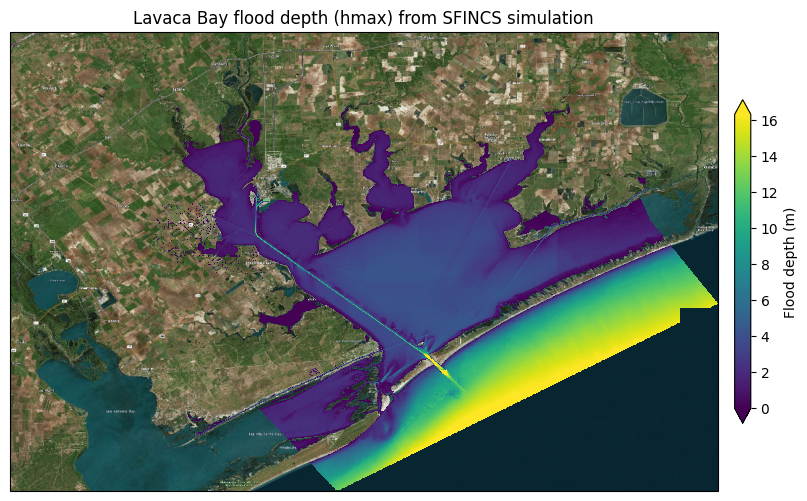

In [ ]:
# Build a cartopy projection that matches the raster CRS.
if raster_crs.is_projected:
    proj = ccrs.epsg(raster_crs.to_epsg())
    data_crs = proj
else:
    proj = ccrs.PlateCarree()
    data_crs = ccrs.PlateCarree()

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(extent, crs=data_crs)

# Satellite background tiles
tiles = cimgt.QuadtreeTiles()
ax.add_image(tiles, 12)

# Overlay flood depth — use a masked array so cartopy renders
# invalid pixels as fully transparent over the satellite tiles.
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)
hmax_plot = np.ma.masked_invalid(hmax_masked)

im = ax.imshow(
    hmax_plot,
    extent=extent,
    origin="upper",
    transform=data_crs,
    cmap=cmap,
    vmin=0,
    vmax=np.nanpercentile(hmax_masked, 98),
    interpolation="nearest",
    zorder=2,
)
fig.colorbar(im, ax=ax, label="Flood depth (m)", shrink=0.6, pad=0.02, extend="both")
ax.set_title("Lavaca Bay flood depth (hmax) from SFINCS simulation")
plt.show()

The flood depth COG can be opened in QGIS or any GIS viewer.
You can also generate a flood depth map outside the pipeline
using the standalone function:

```python
from coastal_calibration.utils.floodmap import create_flood_depth_map

create_flood_depth_map(
    model_root="run/sfincs_model",
    dem_path="../downloads/lavaca_grid/noaa_3m.tif",
)
```

## Summary

This notebook demonstrated the full Lavaca Bay SFINCS workflow via the
Python API:

1. `SfincsCreateConfig.from_dict({...})` + `SfincsCreator(config).run()`
   — built the model from an AOI
2. `CoastalCalibConfig.from_dict({...})` + `CoastalCalibRunner(config).run()`
   — downloaded data, ran SFINCS, and compared results against NOAA observations
3. Inspected the quadtree mesh and its refinement levels
4. Visualized the downscaled flood depth map (`floodmap_hmax.tif`)